In [1]:
from ucimlrepo import fetch_ucirepo 
  

bike_sharing = fetch_ucirepo(id=275) 
  
 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 
  
print(bike_sharing.metadata) 
  

print(bike_sharing.variables) 


{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

Source: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

The goal of this dataset is to predict the total number of rented bikes (cnt)
based on weather conditions, seasonal factors and time variables.

The target variable "cnt" represents the total number of rented bikes
and is a continuous numerical value. Therefore regression models can
be used to predict this variable.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from ucimlrepo import fetch_ucirepo

bike_sharing = fetch_ucirepo(id=275)

X = bike_sharing.data.features
y = bike_sharing.data.targets

df = pd.concat([X,y], axis=1)

df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB


The dataset contains 17,379 observations and 17 variables. Most
variables are numerical and there are no obvious missing values.

In [5]:
df.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

No missing values were detected in the dataset.

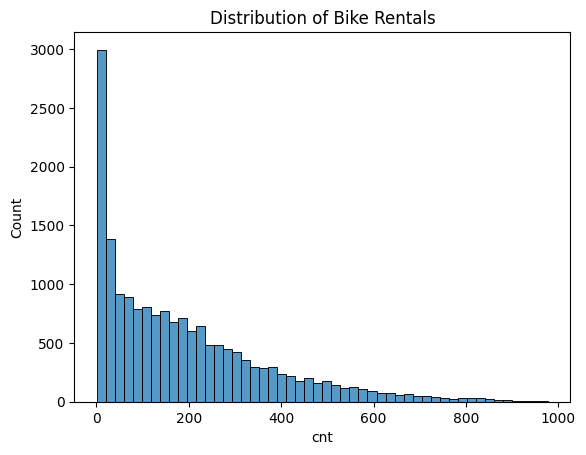

In [6]:
sns.histplot(df["cnt"], bins=50)
plt.title("Distribution of Bike Rentals")
plt.show()

Het histogram laat zien dat het aantal fietsverhuuringen licht rechts-scheef verdeeld is.

Dit geeft aan dat er meer waarnemingen zijn met een laag aantal verhuuringen en minder
met een zeer hoog aantal.

De verdeling is echter niet extreem scheef, wat betekent dat regressiemodellen
nog steeds goed kunnen presteren zonder transformatie.

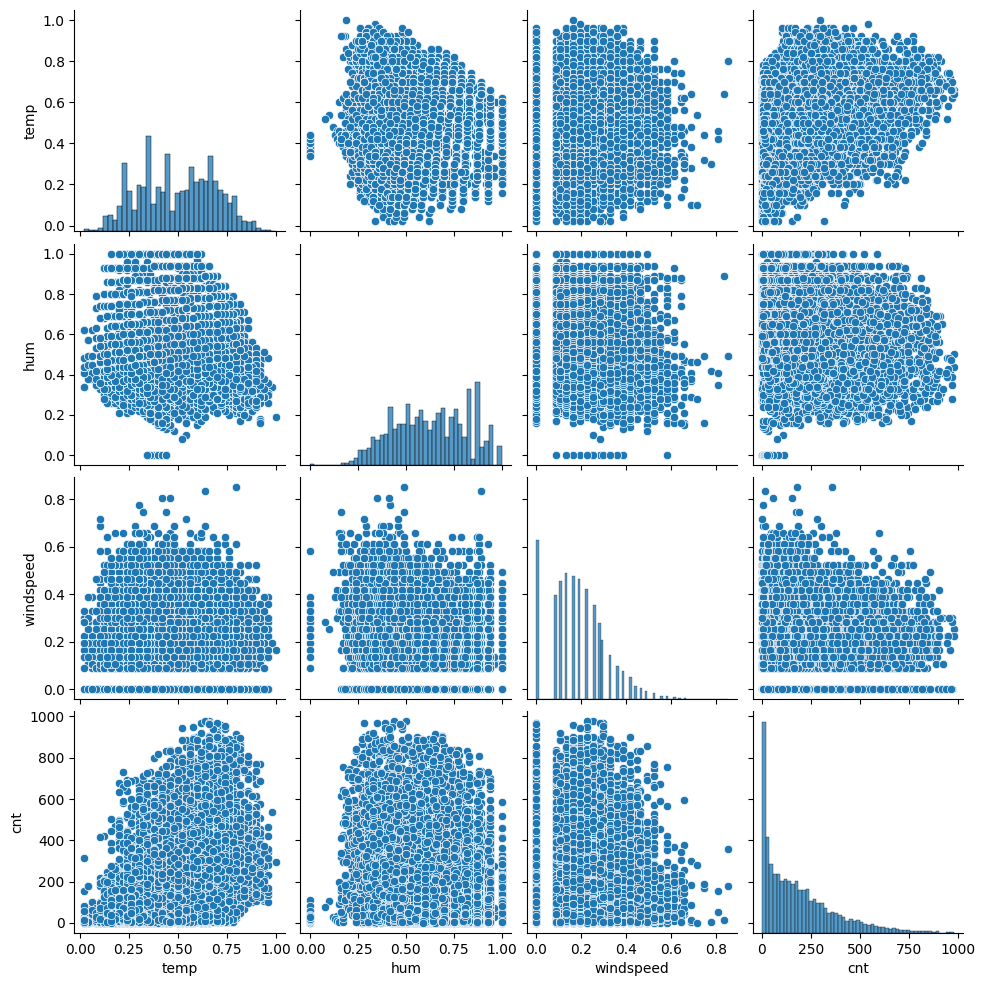

In [7]:
sns.pairplot(df[["temp","hum","windspeed","cnt"]])
plt.show()

In [8]:
df = df.drop("dteday", axis=1)

In [9]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

Regression model

In [11]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50)

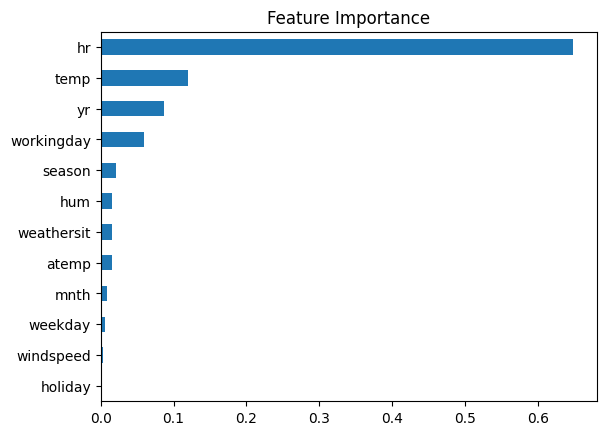

In [13]:
rf.feature_importances_

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

GradientBoostingRegressor()

In [15]:
from sklearn.metrics import r2_score, mean_squared_error

In [16]:
def evaluate(model):

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    return r2, rmse

In [17]:
lr_r2, lr_rmse = evaluate(lr)
rf_r2, rf_rmse = evaluate(rf)
gb_r2, gb_rmse = evaluate(gb)

In [18]:
results = pd.DataFrame({
"Model":["Linear Regression","Random Forest","Gradient Boosting"],
"R2":[lr_r2, rf_r2, gb_r2],
"RMSE":[lr_rmse, rf_rmse, gb_rmse]
})

results

,Model,R2,RMSE
0,Linear Regression,0.387981,139.211452
1,Random Forest,0.919569,50.466734
2,Gradient Boosting,0.849471,69.040251


Random Forest was selected as the best model because it achieved the
highest R² score and the lowest RMSE value compared to the other
models. This indicates that it predicts bike rental demand more
accurately.


In [19]:
best_model = rf

best_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=50)

In [20]:
import joblib

joblib.dump(best_model, "model.joblib", compress=3)

['model.joblib']

In [21]:
def generate_synthetic_data(df, n=1000):
    synthetic = pd.DataFrame()

    for col in df.columns:
        if df[col].dtype in ["int64", "int32"]:
            synthetic[col] = np.random.choice(
                df[col].unique(),
                size=n,
                p=df[col].value_counts(normalize=True).sort_index().values
            )
        else:
            mu, sigma = df[col].mean(), df[col].std()
            synthetic[col] = np.random.normal(mu, sigma, n)

    for col in df.columns:
        synthetic[col] = synthetic[col].clip(df[col].min(), df[col].max())

    return synthetic

synthetic_data = generate_synthetic_data(X, n=1000)



In [22]:
model = joblib.load("model.joblib")
synthetic_data["cnt"] = model.predict(synthetic_data)

synthetic_data.to_csv("synthetic_bike_data.csv", index=False)
print("Synthetic dataset saved!")


Synthetic dataset saved!


Om te controleren of de synthetische dataset realistisch genoeg is, vergelijken we:

- de verdelingen van belangrijke variabelen  
- de correlatiestructuur  
- statistische kenmerken (mean, std, min, max)  

De synthetische data moet lijken op de originele data, maar niet identiek 

In [25]:

#%% md
## 9.1 Statistische vergelijking (mean, std)

comparison_stats = pd.DataFrame({
    "Original Mean": X.mean(),
    "Synthetic Mean": synthetic_data[X.columns].mean(),
    "Original Std": X.std(),
    "Synthetic Std": synthetic_data[X.columns].std()
})

comparison_stats

,Original Mean,Synthetic Mean,Original Std,Synthetic Std
season,2.501640,2.521000,1.106918,1.117501
yr,0.502561,0.489000,0.500008,0.500129
mnth,6.537775,6.535000,3.438776,3.422059
hr,11.546752,11.193000,6.914405,6.973979
holiday,0.028770,0.030000,0.167165,0.170673
weekday,3.003683,2.993000,2.005771,1.995729
workingday,0.682721,0.684000,0.465431,0.465146
weathersit,1.425283,1.399000,0.639357,0.631029
temp,0.496987,0.501968,0.192556,0.196687
atemp,0.475775,0.472237,0.171850,0.170754


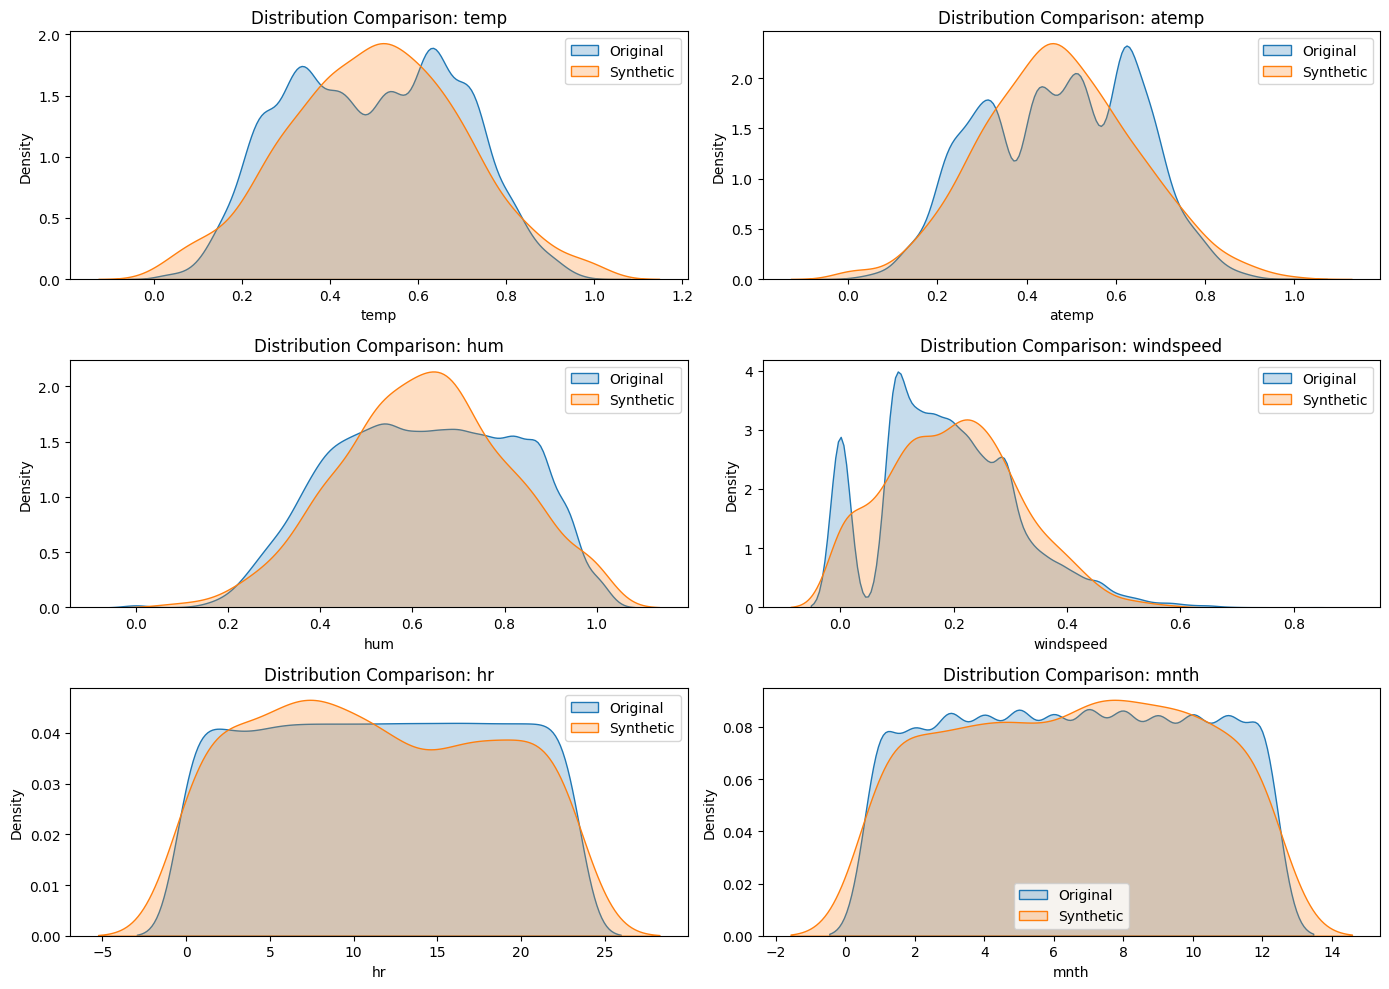

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_compare = ["temp", "atemp", "hum", "windspeed", "hr", "mnth"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(cols_to_compare, 1):
    plt.subplot(3, 2, i)
    sns.kdeplot(X[col], label="Original", fill=True)
    sns.kdeplot(synthetic_data[col], label="Synthetic", fill=True)
    plt.title(f"Distribution Comparison: {col}")
    plt.legend()

plt.tight_layout()
plt.show()


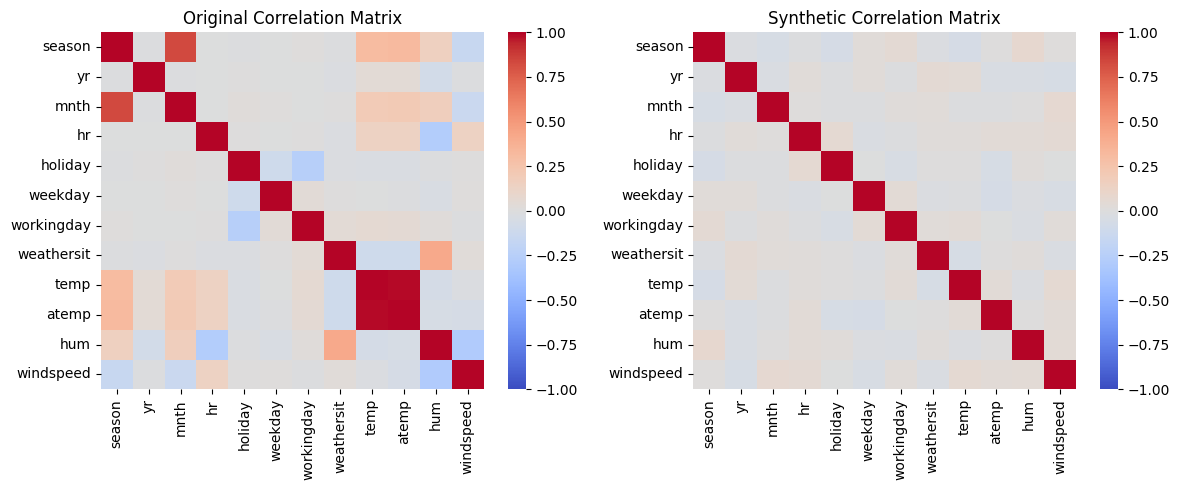

In [30]:
corr_original = X.corr()
corr_synthetic = synthetic_data[X.columns].corr()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(corr_original, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Original Correlation Matrix")

plt.subplot(1, 2, 2)
sns.heatmap(corr_synthetic, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Synthetic Correlation Matrix")

plt.tight_layout()
plt.show()
